In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
import plotly.express as px
import plotly.graph_objects as go
import nbformat

from scipy.stats import ttest_ind, f_oneway,mannwhitneyu
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib_venn import venn2
import os
import scipy.cluster.hierarchy as sch
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

In [2]:
target_CAFs=["FAP", "PDGFRA", "PDGFRB", "S100A4", "LRRC15", "IL1R1", "IL1R2","SMO"]
target_receptors_molecules=["TGFB1","TGFB2","TGFB3", "TGFBR1","TGFBR2","TGFBR3","IL6", "IL6R", "IL10RA","IL10RB", "CXCL8", "CXCL12", 
 "CCR5", "CXCR2", "CXCR1", "CXCR4", "CXCL10","CXCL9","HGF", "MET", "FGF1","FGF2","FGF7","FGF10", "FGFR1","FGFR2","FGFR3","FGFR4","IL11","HAS1","HAS2","HYAL1","HYAL2"]

In [3]:
cell_proportions=pd.read_csv("/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new/bp_res_mid_lvl_ct_updated_ct_fraction_batch_3.csv")


In [4]:
fibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new/fibroblasts_gene_expression_data_new_batch_three_merged_transposed.csv")
print(len(fibr_gene_expression_modified))
cell_proportions=pd.read_csv("/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new/bp_res_mid_lvl_ct_updated_ct_fraction_batch_3.csv")
fibr_gene_expression_modified = pd.merge(
    fibr_gene_expression_modified,
    cell_proportions,
    on="dcc_filename",
    how="inner"  # or "left", "right", "outer" depending on your needs
)
clinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged/9_eyemt_patient_clinical_data_new.csv")
fibr_gene_expression_modified["Patient"]=fibr_gene_expression_modified["Sample"].str.extract(r'(S\d+)')

1130


In [5]:
fibr_gene_expression_modified.drop_duplicates(subset=["dcc_filename"], inplace=True)


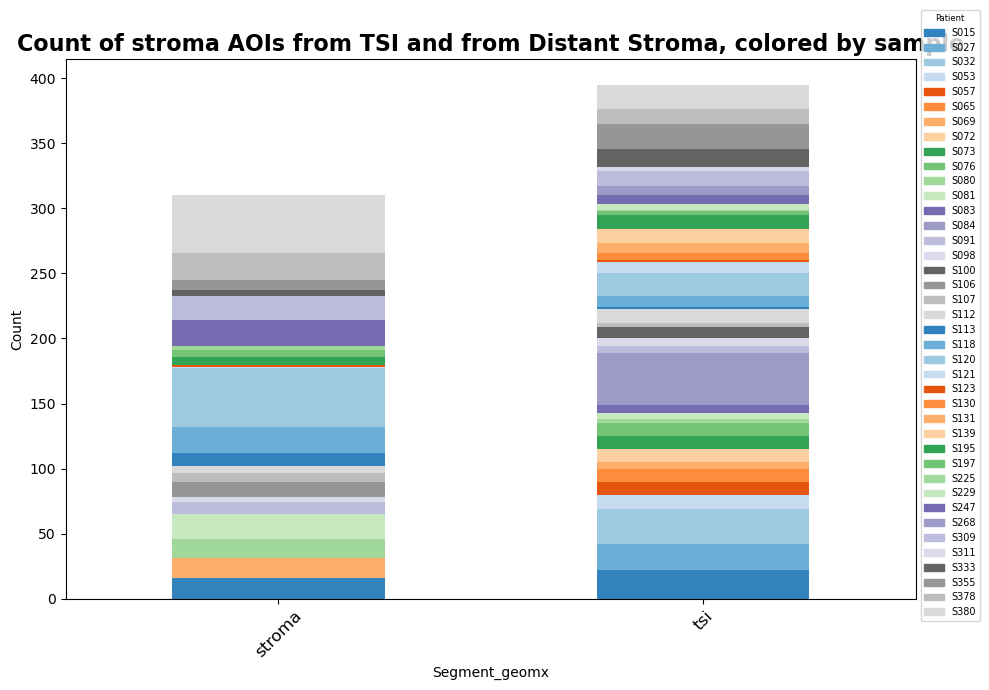

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Step 1: Group data
comb_counts = fibr_gene_expression_modified.groupby(
    ['Segment_geomx', 'Segment', 'Patient']
).size().reset_index(name='count')

# Step 2: Filter to only Segment_y == "stroma"
comb_counts = comb_counts[comb_counts["Segment"] == "stroma"]

# Step 3: Pivot the data so each Patient becomes a column
pivot_df = comb_counts.pivot_table(
    index='Segment_geomx',
    columns='Patient',
    values='count',
    fill_value=0
)

# Step 4: Choose a colormap and assign each patient a unique color
cmap = plt.get_cmap('tab20c')  # Use 'tab20c' or other colormaps with more distinct colors
colors = [cmap(i % cmap.N) for i in range(len(pivot_df.columns))]  # Ensure all patients get a unique color

# Step 5: Plot as stacked bar chart with custom colors
ax = pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    color=colors,  # Fixed order and distinct colors
    legend=False  # Hide default legend
)

# Custom legend
handles = [Patch(color=color, label=patient) for color, patient in zip(colors, pivot_df.columns)]
ax.legend(handles=handles, title="Patient", bbox_to_anchor=(1.0, 1.1), fontsize=7, title_fontsize=6, loc='upper left')

plt.title("Count of stroma AOIs from TSI and from Distant Stroma, colored by sample", fontsize=16,fontweight='bold')
plt.xlabel("Segment_geomx")
plt.ylabel("Count")
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()
plt.show()


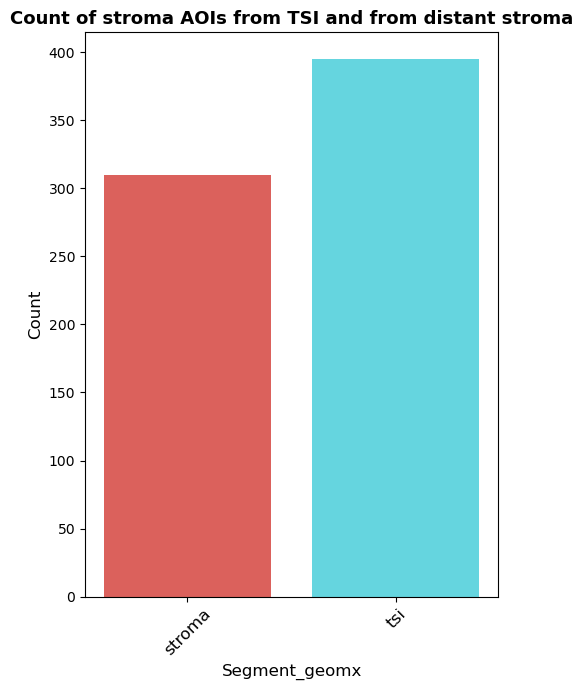

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Group data
comb_counts = fibr_gene_expression_modified.groupby(
    ['Segment_geomx', 'Segment', 'Sample']
).size().reset_index(name='count')

# Step 2: Filter to only Segment == "stroma"
comb_counts = comb_counts[comb_counts["Segment"] == "stroma"]

# Step 3: Pivot so each Patient is a column
pivot_df = comb_counts.pivot_table(
    index='Segment_geomx',
    columns='Sample',
    values='count',
    fill_value=0
)

# Step 4: Define colors for each bar group
bar_colors = [ "#DB615C", "#65D5DF",]

# Step 5: Plot manually bar by bar
fig, ax = plt.subplots(figsize=(5, 7))

for i, (idx, row) in enumerate(pivot_df.iterrows()):
    bottom = 0
    for val in row:
        ax.bar(idx, val, bottom=bottom, color=bar_colors[i])
        bottom += val

plt.title("Count of stroma AOIs from TSI and from distant stroma", fontsize=13, fontweight='bold')
plt.xlabel("Segment_geomx",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()
plt.show()


In [15]:
comb_counts = fibr_gene_expression_modified.groupby(
    ['Segment_geomx', 'Segment', 'Sample']
).size().reset_index(name='count')

# Step 2: Filter to only Segment_y == "stroma"
comb_counts = comb_counts[comb_counts["Segment"] == "stroma"]
comb_counts.sort_values(by='Sample',inplace=True)


In [17]:
# Count occurrences of each sample
sample_counts = comb_counts['Sample'].value_counts()

# Get only those with count == 1
single_occurrence_samples = sample_counts[sample_counts == 1].index

# Filter the original DataFrame
df_single_occurrence = comb_counts[
    comb_counts['Sample'].isin(single_occurrence_samples)
]

df_single_occurrence["Sample"].unique()

array(['S015_post', 'S015_pre', 'S027_post', 'S027_pre', 'S032_pOme',
       'S032_post', 'S032_pre', 'S053_post', 'S057_post', 'S065_post',
       'S072_post', 'S073_post', 'S076_post', 'S083_iOme2', 'S084_pAdn',
       'S084_post', 'S084_pre', 'S100_iOme', 'S106_iOme', 'S130_iOme',
       'S131_iOme', 'S139_iOme', 'S139_pPer', 'S229_iOme', 'S268_iOme',
       'S311_iOme'], dtype=object)

In [18]:
comb_counts

,Segment_geomx,Segment,Sample,count
0,stroma,stroma,S015_iOme,16
26,tsi,stroma,S015_iOme,3
27,tsi,stroma,S015_post,10
28,tsi,stroma,S015_pre,9
29,tsi,stroma,S027_post,9
...,...,...,...,...
72,tsi,stroma,S355_iOme,19
73,tsi,stroma,S378_iOme,11
23,stroma,stroma,S378_iOme,21
24,stroma,stroma,S380_iOme,44


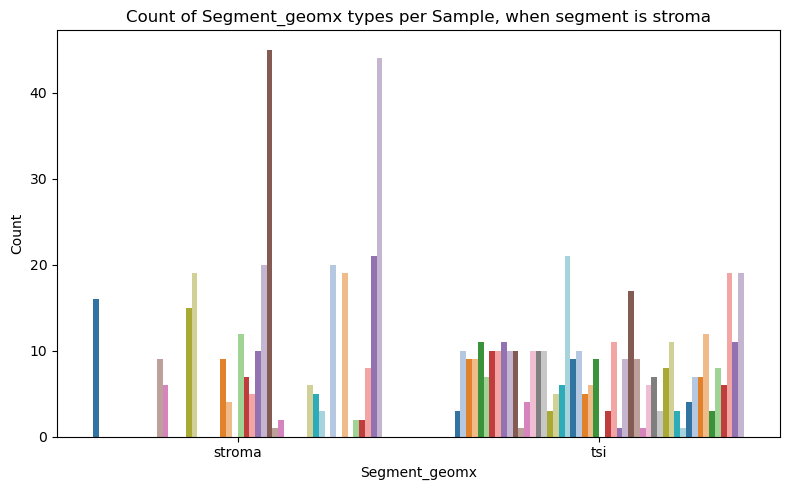

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comb_counts, x='Segment_geomx', y='count', hue='Sample', palette='tab20')

plt.title("Count of Segment_geomx types per Sample, when segment is stroma")
plt.xlabel("Segment_geomx")
plt.ylabel("Count")
plt.legend().remove()
plt.tight_layout()
plt.show()


## Most variable genes extraction

/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


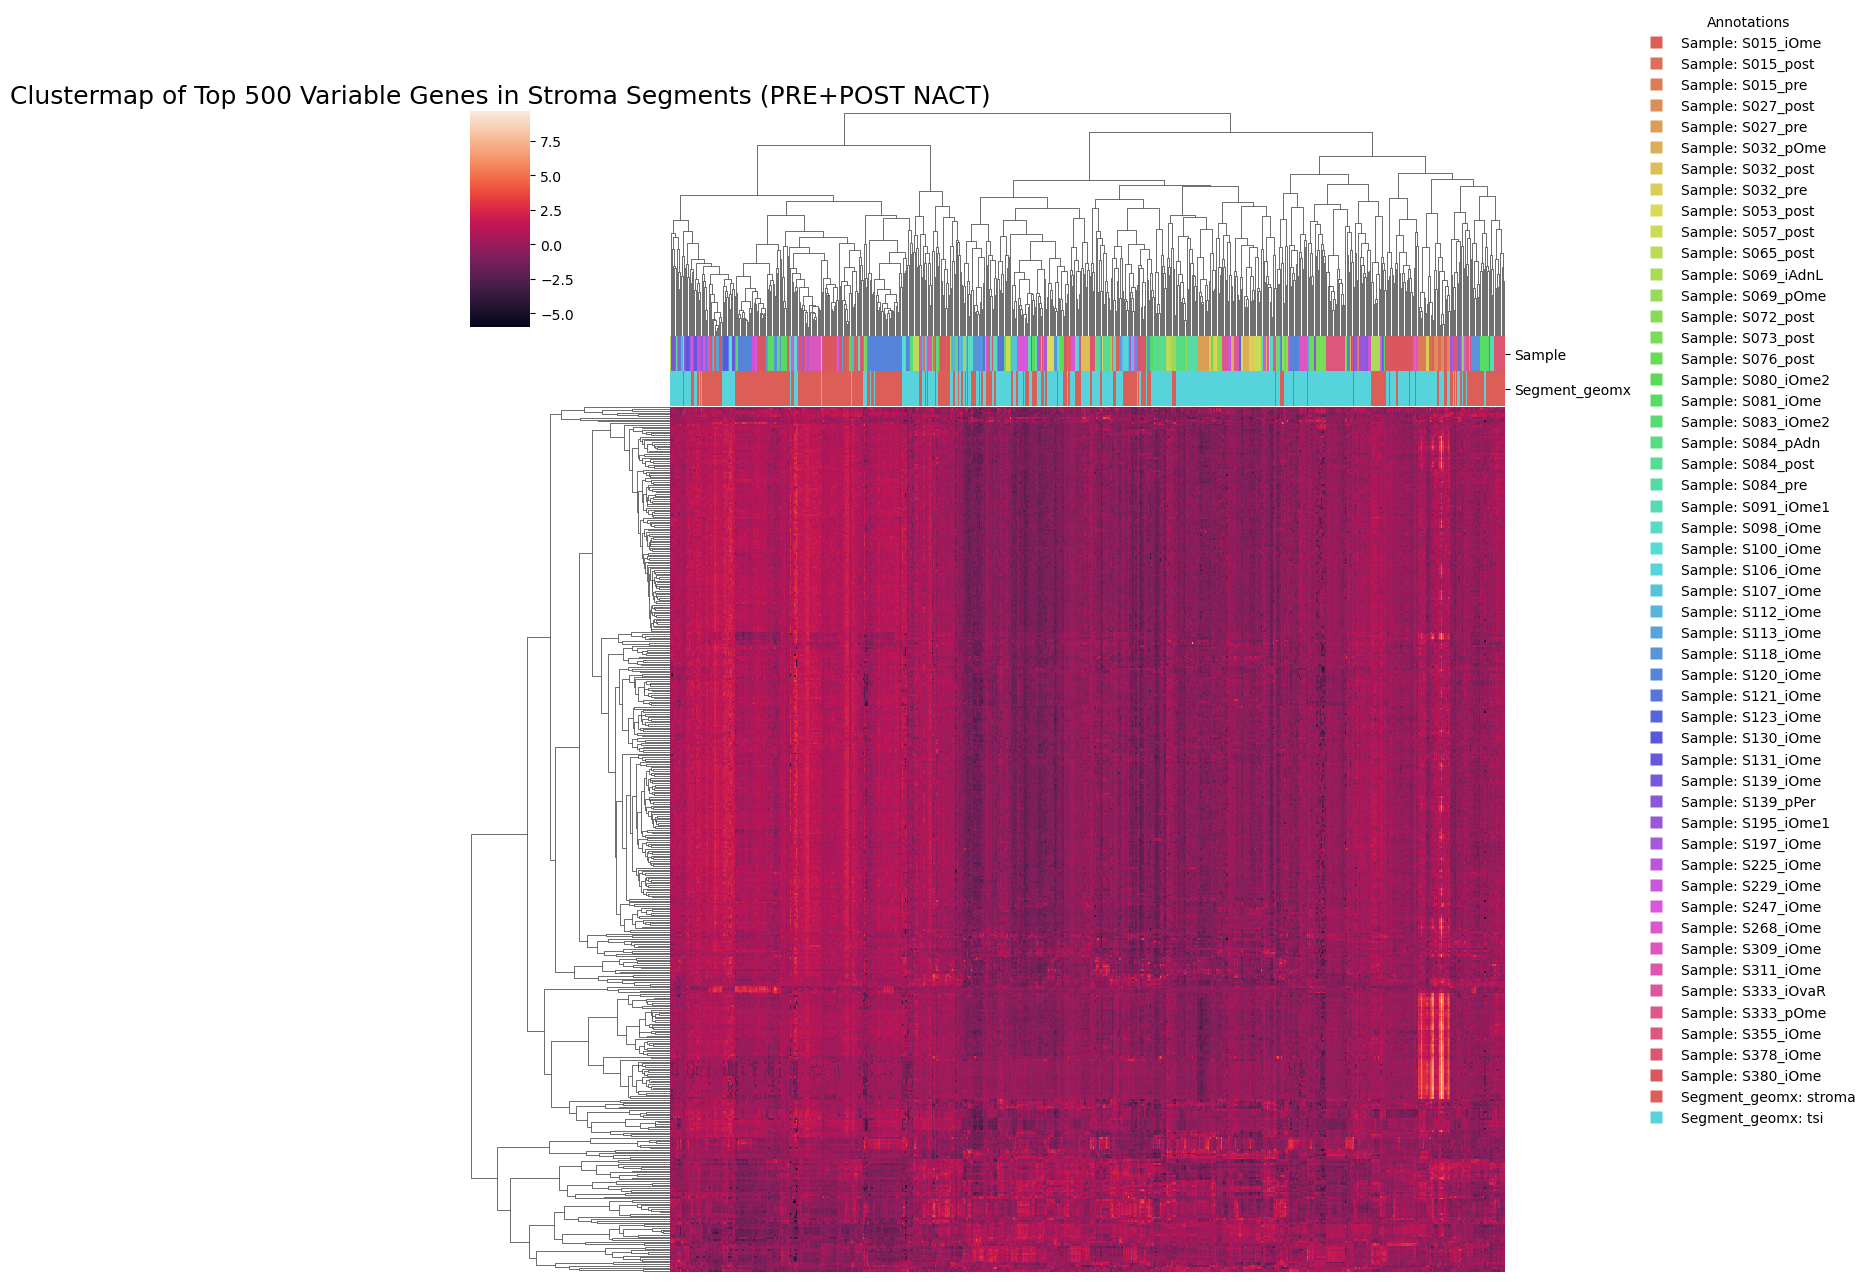

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------
# Build expr_top as you did
# -----------------------

out_dir = Path("/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new")
out_dir.mkdir(parents=True, exist_ok=True)

expr_data = (
    fibr_gene_expression_modified[fibr_gene_expression_modified["Segment"] == "stroma"]
    .select_dtypes(include=[float, int])
    .drop(columns=['PFS_quartile_b123', 'OS_quartile_b123'], errors='ignore')
)

gene_variance = expr_data.var(axis=0)
top_genes = gene_variance.sort_values(ascending=False).head(500).index
expr_top = expr_data[top_genes]  # rows = samples, cols = genes
pd.Series(top_genes, name="gene").to_csv(out_dir / "top_variable_500_genes_stroma_tsi_post_pre.csv", index=False)
# -----------------------
# Choose annotation variables from the ORIGINAL df (categorical)
# -----------------------
annot_vars = ["Sample", "Segment_geomx"]  # add/remove as needed

# Keep only those that actually exist
annot_vars = [v for v in annot_vars if v in fibr_gene_expression_modified.columns]

# Slice annotations for the SAME samples in expr_top (match row order)
ann = fibr_gene_expression_modified.loc[expr_top.index, annot_vars].copy()

# -----------------------
# Map each annotation level to a color
# -----------------------
color_maps = {}
for var in annot_vars:
    levels = pd.Categorical(ann[var]).categories  # stable ordering
    palette = sns.color_palette("hls", len(levels))
    color_maps[var] = dict(zip(levels, palette))
    
# Build col_colors (index must match the samples = expr_top.index)
col_colors = pd.DataFrame(
    {var: ann[var].map(color_maps[var]) for var in annot_vars},
    index=expr_top.index
)


meta_cols = ["dcc_filename", "Segment", "Segment_geomx"]
# keep only those that exist
meta_cols = [c for c in meta_cols if c in fibr_gene_expression_modified.columns]

filtered_df = (
    fibr_gene_expression_modified.loc[fibr_gene_expression_modified["Segment"] == "stroma", meta_cols + list(top_genes)]
)

# Save the filtered dataframe
filtered_df.to_csv(out_dir / "stroma_top500_with_metadata_post_pre.csv", index=False)
# -----------------------
# Clustermap (genes as rows, samples as columns)
# -----------------------
g = sns.clustermap(
    expr_top.T,
    method='complete',
    metric='correlation',
    z_score=0,
    col_colors=col_colors,   # <-- annotate samples (columns)
    xticklabels=False,
    yticklabels=False,
    figsize=(12, 12)
)

# -----------------------
# Legend for the annotations
# -----------------------
handles, labels = [], []
for var in annot_vars:
    for level, color in color_maps[var].items():
        handles.append(plt.Line2D([0], [0], marker='s', linestyle='',
                                  markerfacecolor=color, markeredgecolor='none', markersize=8))
        labels.append(f"{var}: {level}")

# Place legend to the right of the heatmap
g.ax_col_dendrogram.legend(
    handles, labels, title="Annotations",
    loc="center left", bbox_to_anchor=(1.15, -1), frameon=False
)

plt.title("Clustermap of Top 500 Variable Genes in Stroma Segments (PRE+POST NACT)", loc="center", fontsize=18)
plt.show()


/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


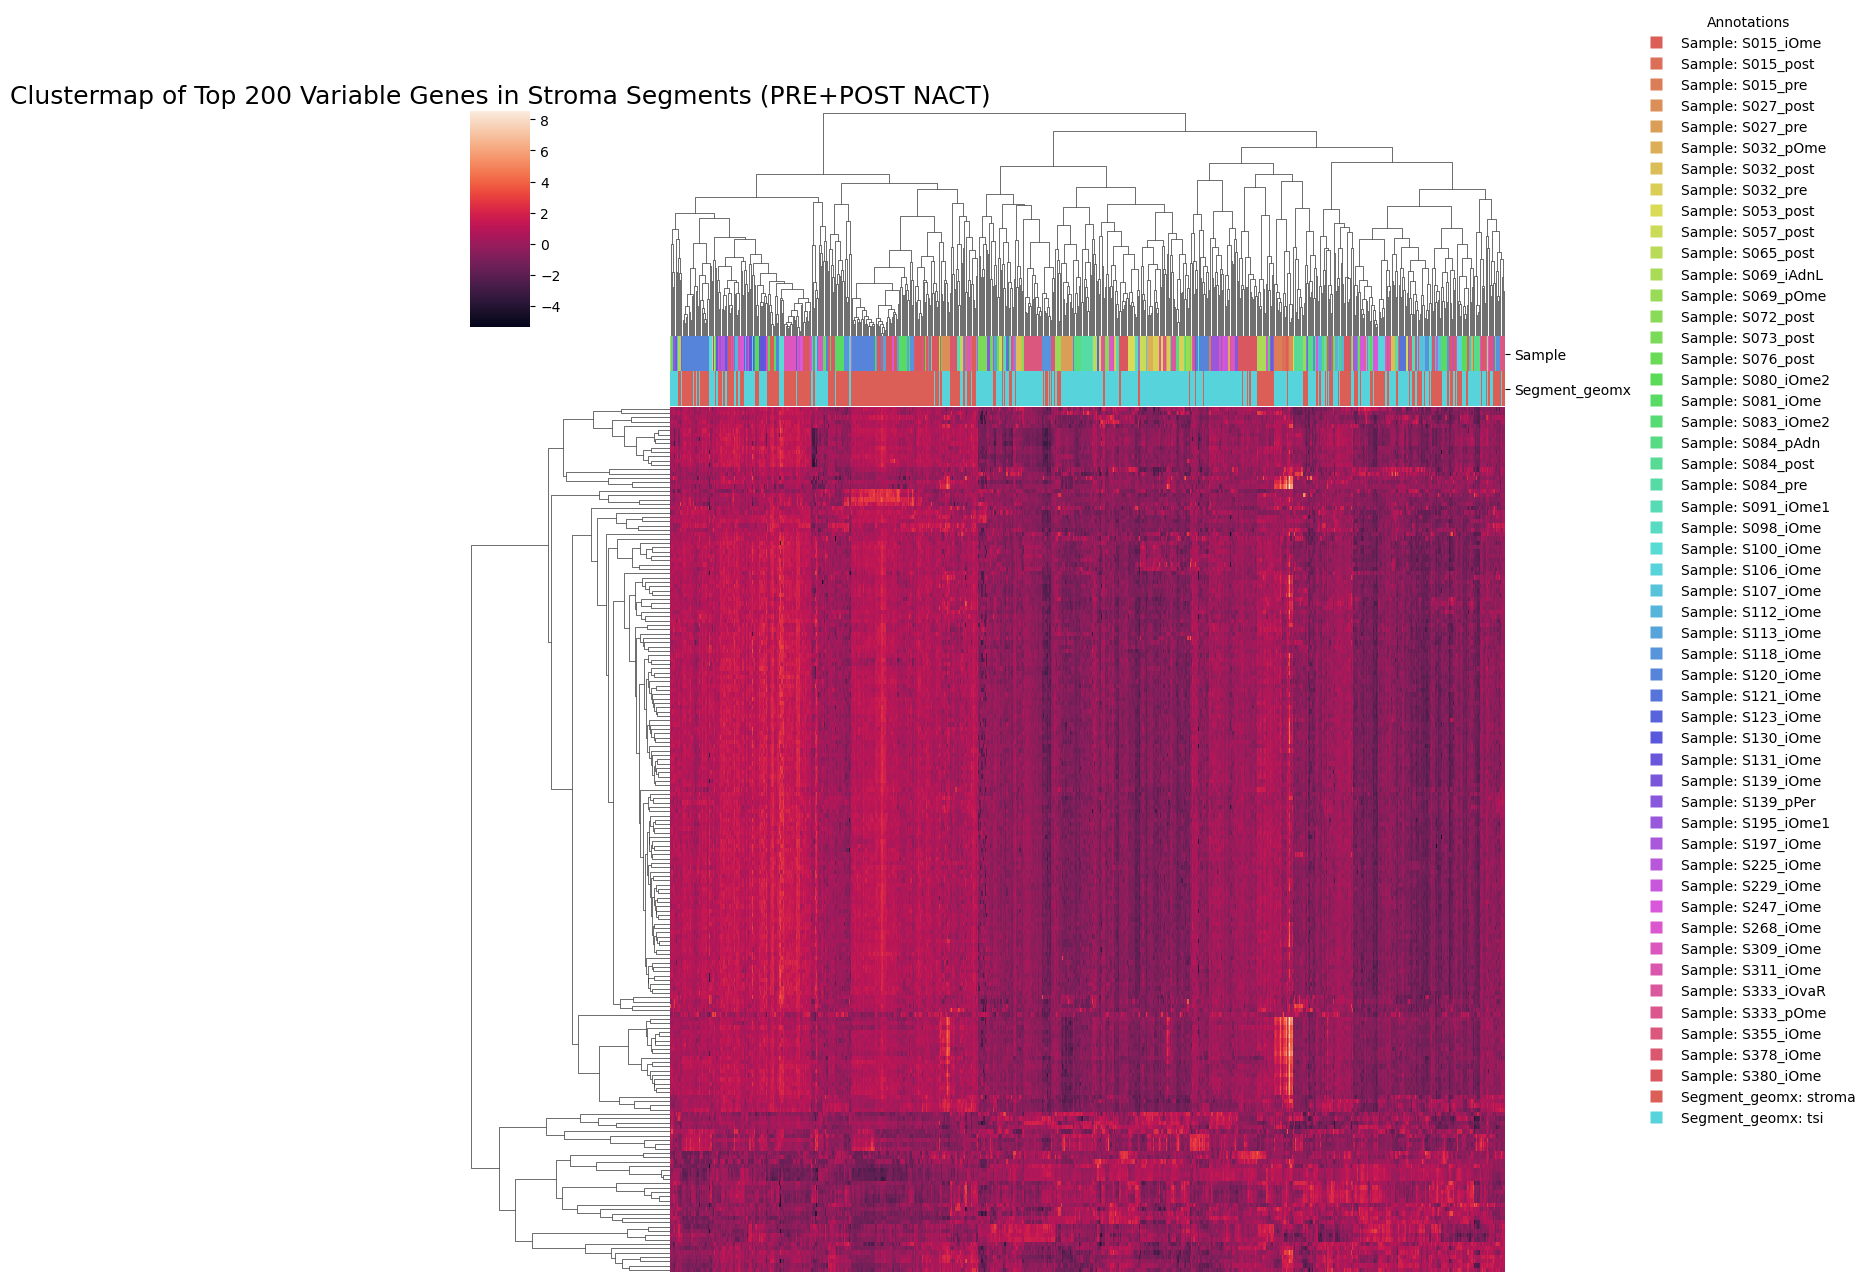

In [20]:
out_dir = Path("/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new")
out_dir.mkdir(parents=True, exist_ok=True)

expr_data = (
    fibr_gene_expression_modified[fibr_gene_expression_modified["Segment"] == "stroma"]
    .select_dtypes(include=[float, int])
    .drop(columns=['PFS_quartile_b123', 'OS_quartile_b123'], errors='ignore')
)

gene_variance = expr_data.var(axis=0)
top_genes = gene_variance.sort_values(ascending=False).head(200).index
expr_top = expr_data[top_genes]  # rows = samples, cols = genes
pd.Series(top_genes, name="gene").to_csv(out_dir / "top_variable_200_genes_stroma_tsi_pre_post.csv", index=False)
# -----------------------
# Choose annotation variables from the ORIGINAL df (categorical)
# -----------------------
annot_vars = ["Sample", "Segment_geomx"]  # add/remove as needed

# Keep only those that actually exist
annot_vars = [v for v in annot_vars if v in fibr_gene_expression_modified.columns]

# Slice annotations for the SAME samples in expr_top (match row order)
ann = fibr_gene_expression_modified.loc[expr_top.index, annot_vars].copy()

# -----------------------
# Map each annotation level to a color
# -----------------------
color_maps = {}
for var in annot_vars:
    levels = pd.Categorical(ann[var]).categories  # stable ordering
    palette = sns.color_palette("hls", len(levels))
    color_maps[var] = dict(zip(levels, palette))
    
# Build col_colors (index must match the samples = expr_top.index)
col_colors = pd.DataFrame(
    {var: ann[var].map(color_maps[var]) for var in annot_vars},
    index=expr_top.index
)


meta_cols = ["dcc_filename", "Segment", "Segment_geomx"]
# keep only those that exist
meta_cols = [c for c in meta_cols if c in fibr_gene_expression_modified.columns]

filtered_df = (
    fibr_gene_expression_modified.loc[fibr_gene_expression_modified["Segment"] == "stroma", meta_cols + list(top_genes)]
)

# Save the filtered dataframe
filtered_df.to_csv(out_dir / "stroma_top200_with_metadata_pre_post.csv", index=False)
# -----------------------
# Clustermap (genes as rows, samples as columns)
# -----------------------
g = sns.clustermap(
    expr_top.T,
    method='complete',
    metric='correlation',
    z_score=0,
    col_colors=col_colors,   # <-- annotate samples (columns)
    xticklabels=False,
    yticklabels=False,
    figsize=(12, 12)
)

# -----------------------
# Legend for the annotations
# -----------------------
handles, labels = [], []
for var in annot_vars:
    for level, color in color_maps[var].items():
        handles.append(plt.Line2D([0], [0], marker='s', linestyle='',
                                  markerfacecolor=color, markeredgecolor='none', markersize=8))
        labels.append(f"{var}: {level}")

# Place legend to the right of the heatmap
g.ax_col_dendrogram.legend(
    handles, labels, title="Annotations",
    loc="center left", bbox_to_anchor=(1.15, -1), frameon=False
)

plt.title("Clustermap of Top 200 Variable Genes in Stroma Segments (PRE+POST NACT)", loc="center", fontsize=18)
plt.show()

/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


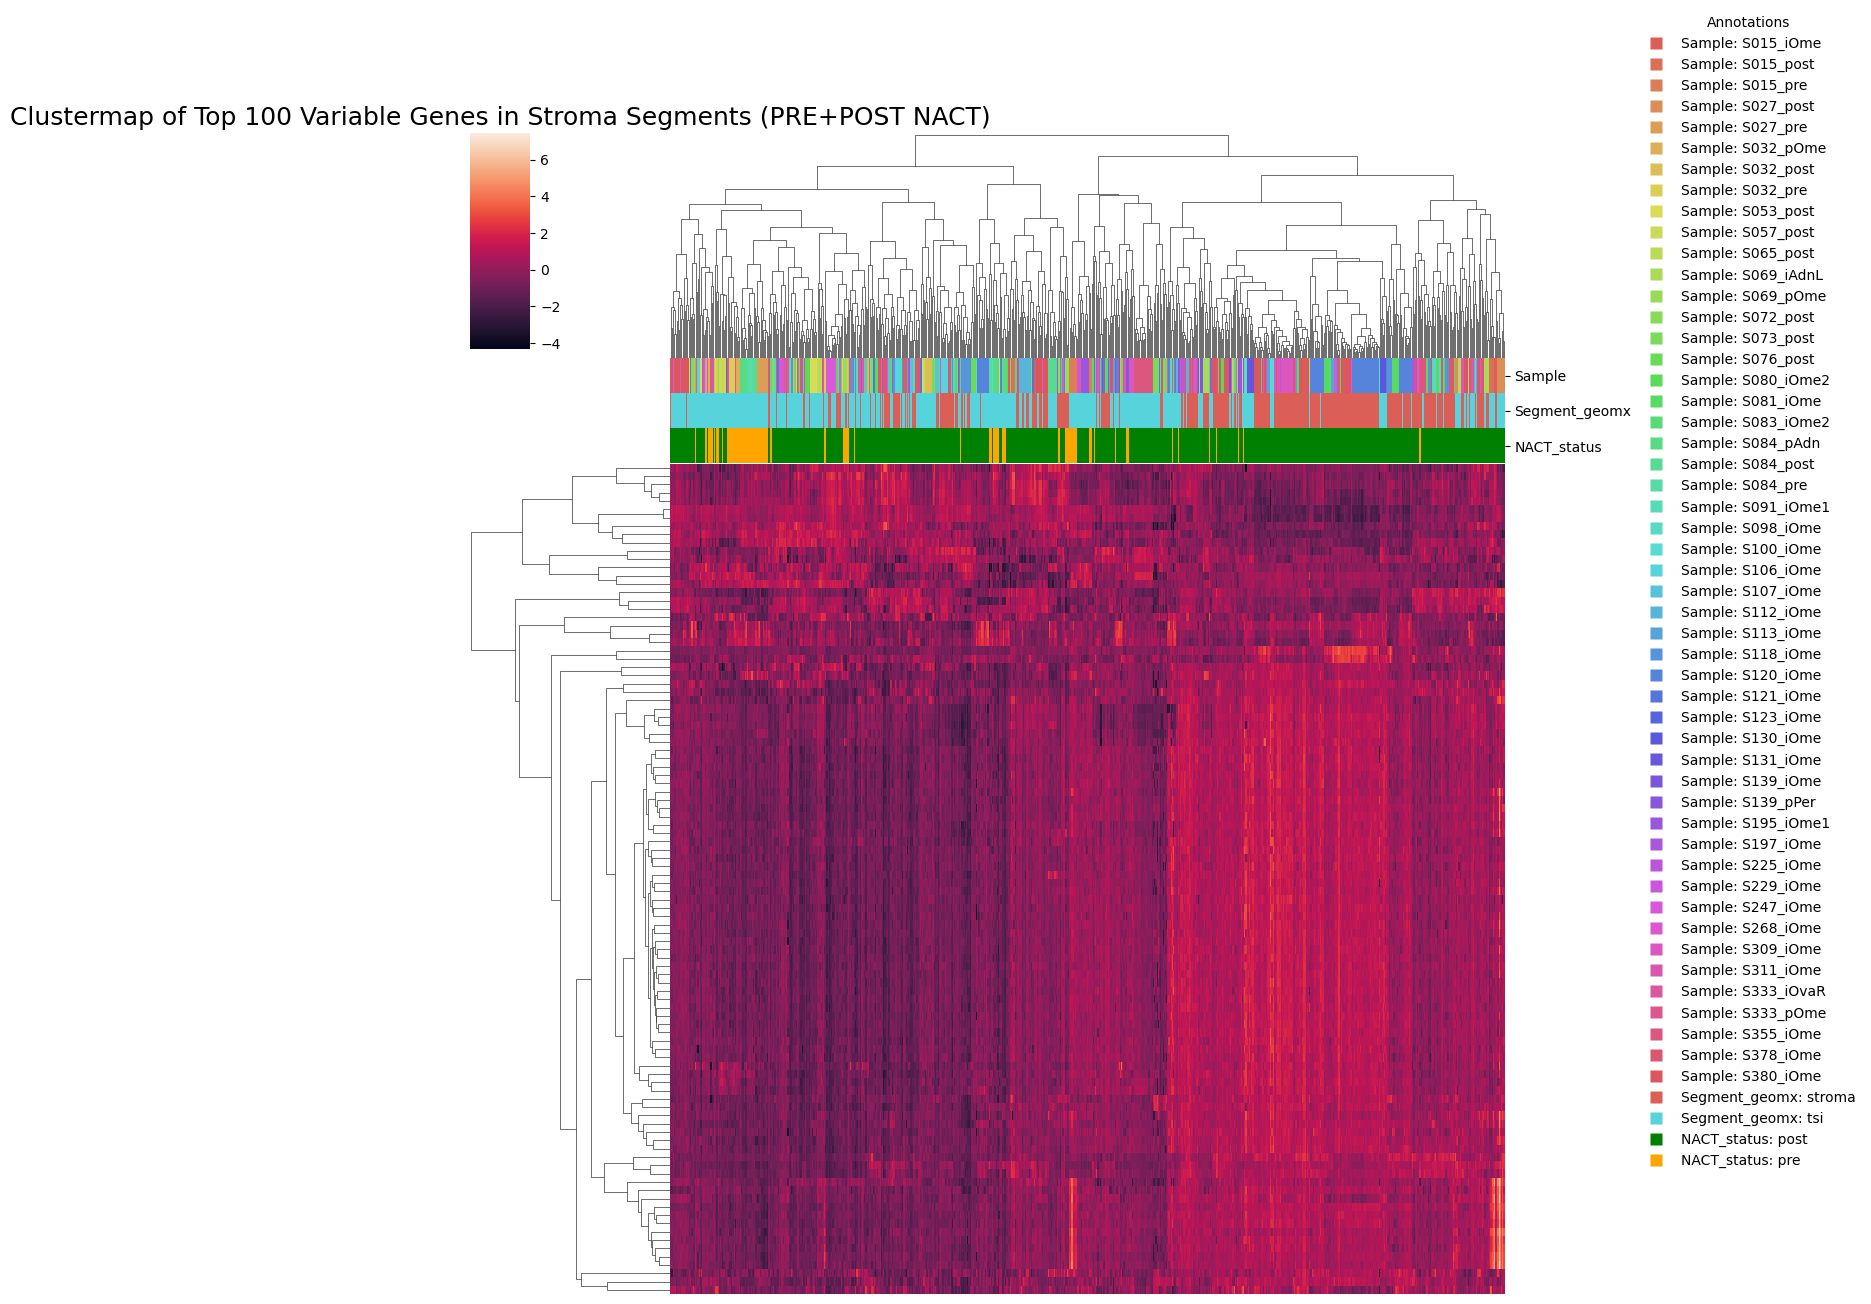

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


out_dir = Path("/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new")
out_dir.mkdir(parents=True, exist_ok=True)

expr_data = (
    fibr_gene_expression_modified[fibr_gene_expression_modified["Segment"] == "stroma"]
    .select_dtypes(include=[float, int])
    .drop(columns=['PFS_quartile_b123', 'OS_quartile_b123'], errors='ignore')
)

gene_variance = expr_data.var(axis=0)
top_genes = gene_variance.sort_values(ascending=False).head(100).index
expr_top = expr_data[top_genes]  # rows = samples, cols = genes
pd.Series(top_genes, name="gene").to_csv(out_dir / "top_variable_100_genes_stroma_tsi_pre_post.csv", index=False)
# -----------------------
# Choose annotation variables from the ORIGINAL df (categorical)
# -----------------------
annot_vars = ["Sample", "Segment_geomx","NACT_status"]  # add/remove as needed

# Keep only those that actually exist
annot_vars = [v for v in annot_vars if v in fibr_gene_expression_modified.columns]

# Slice annotations for the SAME samples in expr_top (match row order)
ann = fibr_gene_expression_modified.loc[expr_top.index, annot_vars].copy()

# -----------------------
# Map each annotation level to a color
# -----------------------
color_maps = {}

for var in annot_vars:
    levels = pd.Categorical(ann[var]).categories

    if var == "NACT_status":
        # Soft, publication-friendly colors
        custom_palette = {
            "pre":  "orange",   # teal
            "post": "green"    # soft orange
        }
        color_maps[var] = {lvl: custom_palette.get(lvl, "lightgray") for lvl in levels}

    else:
        palette = sns.color_palette("hls", len(levels))
        color_maps[var] = dict(zip(levels, palette))

    
# Build col_colors (index must match the samples = expr_top.index)
col_colors = pd.DataFrame(
    {var: ann[var].map(color_maps[var]) for var in annot_vars},
    index=expr_top.index
)


meta_cols = ["dcc_filename", "Segment", "Segment_geomx"]
# keep only those that exist
meta_cols = [c for c in meta_cols if c in fibr_gene_expression_modified.columns]

filtered_df = (
    fibr_gene_expression_modified.loc[fibr_gene_expression_modified["Segment"] == "stroma", meta_cols + list(top_genes)]
)

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# -----------------------
# Define groups
# -----------------------
group_col = "Segment_geomx"   # this column distinguishes stroma vs TSI
stroma_label = "stroma"
tsi_label = "tsi"

gene_cols = list(top_genes)

# Subset to expression only
expr = filtered_df[gene_cols]
groups = filtered_df[group_col]

# -----------------------
# Compute means + p-values
# -----------------------
results = []

for gene in gene_cols:
    stroma_vals = expr.loc[groups == stroma_label, gene].dropna()
    tsi_vals    = expr.loc[groups == tsi_label, gene].dropna()

    if len(stroma_vals) < 2 or len(tsi_vals) < 2:
        p = np.nan
    else:
        p = ttest_ind(stroma_vals, tsi_vals, equal_var=False).pvalue

    stroma_mean = stroma_vals.mean()
    tsi_mean    = tsi_vals.mean()

    results.append([gene, p, stroma_mean, tsi_mean])

res = pd.DataFrame(results, columns=["gene", "p_value", "stroma_mean", "tsi_mean"])

# -----------------------
# Multiple testing correction
# -----------------------
res["padj"] = multipletests(res["p_value"], method="fdr_bh")[1]
res["significant"] = res["padj"] < 0.05

# -----------------------
# Direction flags
# -----------------------
res["TSI_higher"] = res["tsi_mean"] > res["stroma_mean"]
res["TSI_upregulated"] = res["TSI_higher"] & res["significant"]

# Sort by p-value like a DE table
res = res.sort_values("p_value")

# -----------------------
# Save
# -----------------------
res.to_csv(out_dir / "stroma_vs_tsi_DE_table_top100.csv", index=False)


# Save the filtered dataframe
filtered_df.to_csv(out_dir / "stroma_top100_with_metadata_pre_post.csv", index=False)
# -----------------------
# Clustermap (genes as rows, samples as columns)
# -----------------------
g = sns.clustermap(
    expr_top.T,
    method='complete',
    metric='correlation',
    z_score=0,
    col_colors=col_colors,   # <-- annotate samples (columns)
    xticklabels=False,
    yticklabels=False,
    figsize=(12, 12)
)

# -----------------------
# Legend for the annotations
# -----------------------
handles, labels = [], []
for var in annot_vars:
    for level, color in color_maps[var].items():
        handles.append(plt.Line2D([0], [0], marker='s', linestyle='',
                                  markerfacecolor=color, markeredgecolor='none', markersize=8))
        labels.append(f"{var}: {level}")

# Place legend to the right of the heatmap
g.ax_col_dendrogram.legend(
    handles, labels, title="Annotations",
    loc="center left", bbox_to_anchor=(1.15, -1), frameon=False
)

plt.title("Clustermap of Top 100 Variable Genes in Stroma Segments (PRE+POST NACT)", loc="center", fontsize=18)
plt.show()

/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


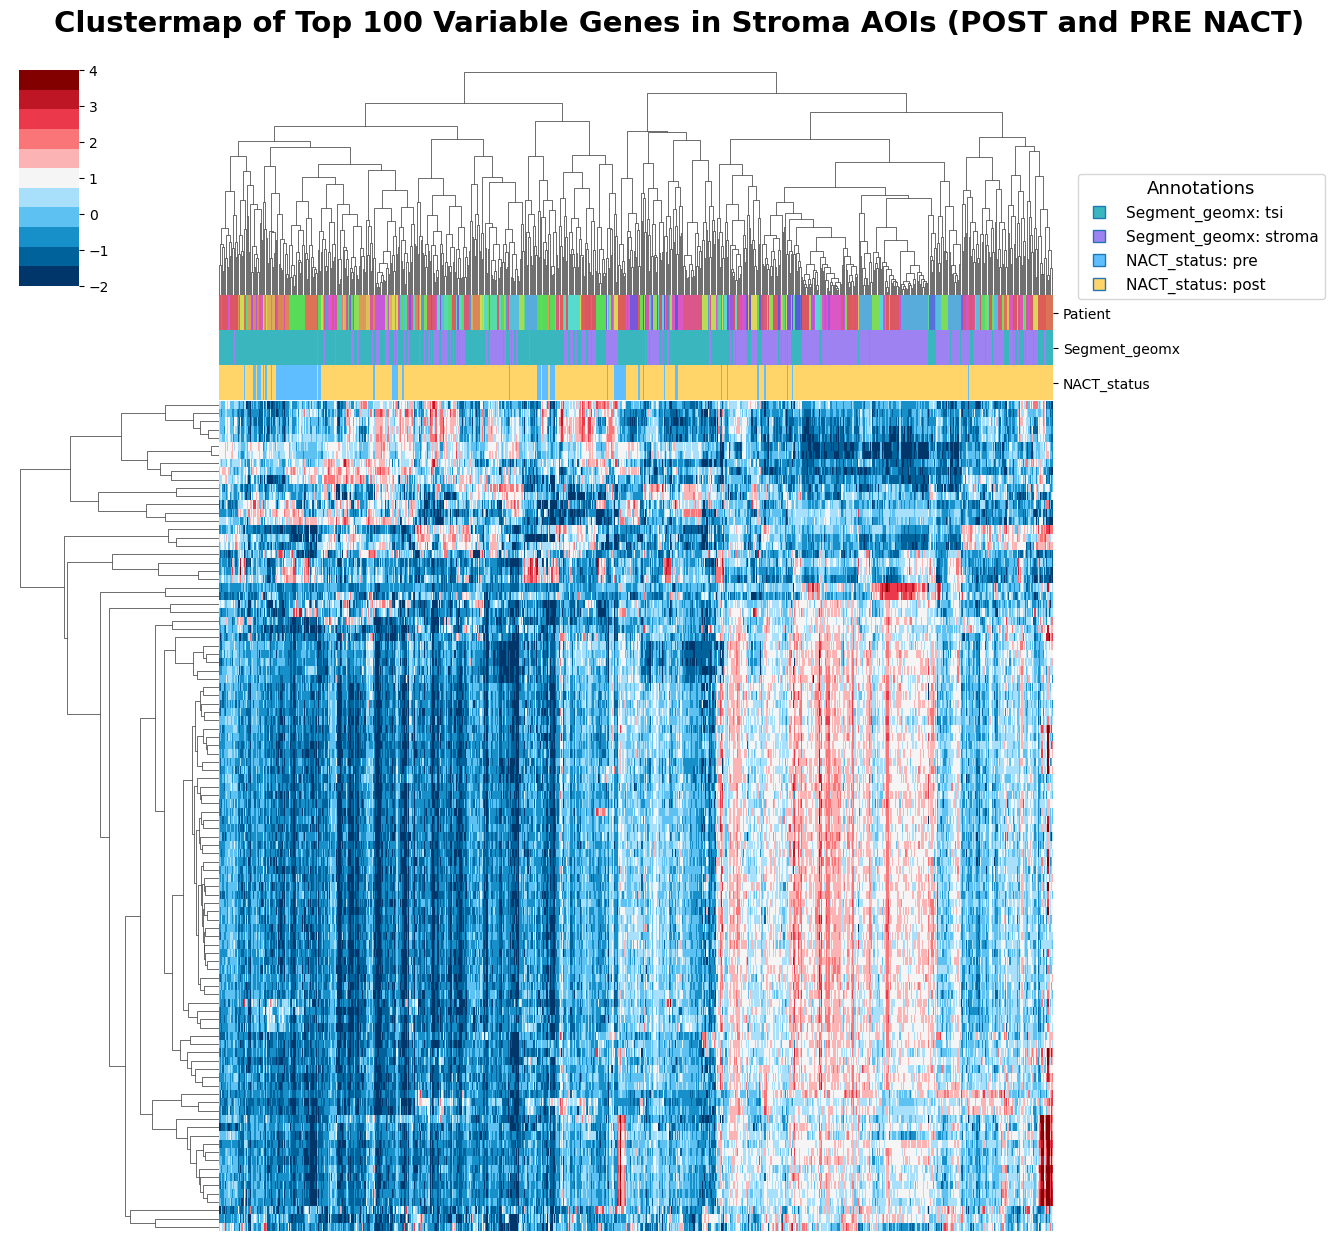

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import ListedColormap

# -----------------------
# Custom heatmap palette
# -----------------------
custom_cmap = ListedColormap([
    "#00366a", "#00629b", "#1790c9", "#5dc1f1", "#a8e0fb", 
    "#f5f5f5", "#fbb4b3", "#fa7578", "#eb394b", "#be1624", "#830000"
])

# -----------------------
# Annotation colors
# -----------------------
segment_colors = {
    "tsi": "#3ab7be",
    "stroma": "#9e82f2"
}

nact_colors = {
    "pre": "#5ebeff",
    "post": "#ffd468"
}

# -----------------------
# Output directory
# -----------------------
out_dir = Path("/Users/nikamikhailava/Desktop/batch_merged_new")
out_dir.mkdir(parents=True, exist_ok=True)

# -----------------------
# Expression data: top 100 genes by variance
# -----------------------
expr_data = (
    fibr_gene_expression_modified[fibr_gene_expression_modified["Segment"] == "stroma"]
    .select_dtypes(include=[float, int])
    .drop(columns=['PFS_quartile_b123', 'OS_quartile_b123'], errors='ignore')
)

top_genes = expr_data.var(axis=0).sort_values(ascending=False).head(100).index
expr_top = expr_data[top_genes]

# Save top genes
pd.Series(top_genes, name="gene").to_csv(out_dir / "top_variable_100_genes_stroma_tsi_pre_post.csv", index=False)

# -----------------------
# Annotations
# -----------------------
annot_vars = ["Patient", "Segment_geomx","NACT_status"]
annot_vars = [v for v in annot_vars if v in fibr_gene_expression_modified.columns]
ann = fibr_gene_expression_modified.loc[expr_top.index, annot_vars].copy()

# Remove extra spaces if any
ann["Segment_geomx"] = ann["Segment_geomx"].str.strip()
ann["NACT_status"] = ann["NACT_status"].str.strip()

# Map annotation colors
color_maps = {
    "Segment_geomx": ann["Segment_geomx"].map(segment_colors),
    "NACT_status": ann["NACT_status"].map(nact_colors)
}

# Other annotations (e.g., Patient) get an automatic palette
for var in annot_vars:
    if var not in color_maps:
        levels = pd.Categorical(ann[var]).categories
        palette = sns.color_palette("hls", len(levels))
        color_maps[var] = dict(zip(levels, palette))
        color_maps[var] = ann[var].map(color_maps[var])

# Build col_colors dataframe
col_colors = pd.DataFrame({var: color_maps[var] for var in annot_vars}, index=expr_top.index)

# -----------------------
# Clustermap
# -----------------------
g = sns.clustermap(
    expr_top.T,
    method='complete',
    metric='correlation',
    z_score=0,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=False,
    figsize=(12, 12),
    vmin=-2,
    vmax=4,
    cmap=custom_cmap
)

# -----------------------
# Legend for annotations
# -----------------------
handles, labels = [], []
for var in annot_vars:
    if var != "Patient":  # Skip Patient if desired
        for level, color in (segment_colors if var=="Segment_geomx" else nact_colors).items():
            handles.append(plt.Line2D([0], [0], marker='s', linestyle='', 
                                      markerfacecolor=color, markersize=8))
            labels.append(f"{var}: {level}")

g.ax_col_dendrogram.legend(
    handles, labels, title="Annotations",
    loc="center left", bbox_to_anchor=(1.02, 0.25), frameon=True, fontsize=11, title_fontsize=13
)

# -----------------------
# Title
# -----------------------
plt.title(
    "Clustermap of Top 100 Variable Genes in Stroma AOIs (POST and PRE NACT)", 
    loc="center", 
    fontsize=21,
    fontweight="bold",  # Make the title bold
    pad=20 , # Increase the distance between the title and the plot (optional)
    x=11,  # Center horizontally
    y=1.05
)

plt.show()


## Find out the genes more expressed in TSI fibroblasts

/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette

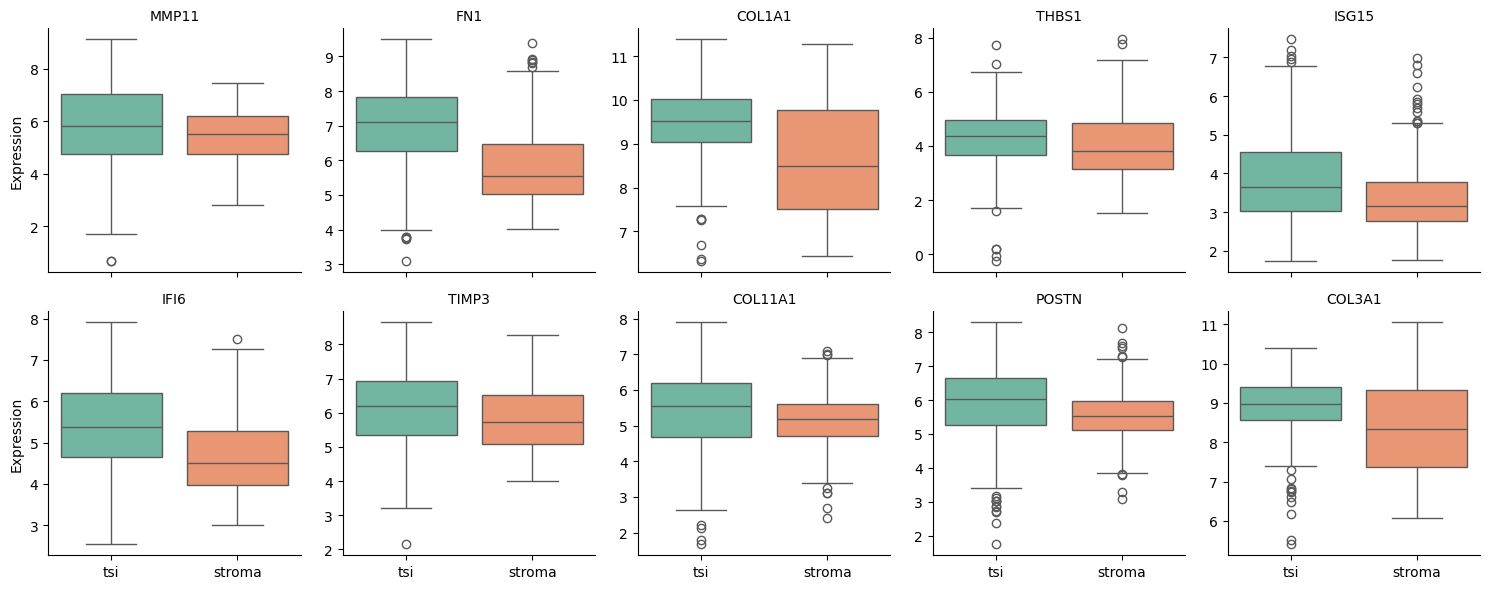

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import mannwhitneyu

# Top 100 genes from earlier
genes_top100 = list(top_genes)

# 1) Select only rows where Segment_geomx is stroma or tsi
df_plot = fibr_gene_expression_modified[ (fibr_gene_expression_modified["Segment"] == "stroma") &
    fibr_gene_expression_modified["Segment_geomx"].isin(["stroma", "tsi"])
][["Segment_geomx"] + genes_top100]

# 2) Melt to long format
df_long = df_plot.melt(
    id_vars="Segment_geomx",
    value_vars=genes_top100,
    var_name="gene",
    value_name="expression"
)

# 3) Perform Mann-Whitney U tests for each gene and store p-values and mean expression
p_values = {}
mean_expression = {}

for gene in genes_top100:
    group_stroma = df_long[(df_long["Segment_geomx"] == "stroma") & (df_long["gene"] == gene)]["expression"]
    group_tsi = df_long[(df_long["Segment_geomx"] == "tsi") & (df_long["gene"] == gene)]["expression"]
    
    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_stroma, group_tsi, alternative="two-sided")
    
    # Store p-value and mean expression for both groups
    p_values[gene] = p_value
    mean_expression[gene] = {
        "stroma_mean": group_stroma.mean(),
        "tsi_mean": group_tsi.mean()
    }

# 4) Filter genes that have a significant difference (p < 0.05) and higher expression in TSI
significant_genes_tsi_higher = [
    gene for gene, p in p_values.items() 
    if p < 0.05 and mean_expression[gene]["tsi_mean"] > mean_expression[gene]["stroma_mean"]
]

# 5) Filter df_long to include only significant genes where TSI expression is higher
df_filtered = df_long[df_long["gene"].isin(significant_genes_tsi_higher)]

# 6) FacetGrid: one small boxplot per gene, 2 boxes each (stroma vs tsi)
g = sns.FacetGrid(
    df_filtered,
    col="gene",
    col_wrap=5,       # How many plots per row
    sharey=False,
    height=3
)
g.map_dataframe(
    sns.boxplot,
    x="Segment_geomx",
    y="expression",
    palette="Set2"
)
g.set_titles("{col_name}")
g.set_xlabels("")
g.set_ylabels("Expression")

plt.tight_layout()
plt.show()
